<a href="https://colab.research.google.com/github/LujainAldujain/Data_Mining_Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Summarization and Preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Attributes:")
print(numeric_columns)

Numerical Attributes:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


### Numerical Attributes

The numerical attributes were identified based on their data types. These attributes will be used to calculate the five-number summary, detect potential outliers, and generate boxplots.

In [3]:
five_number_summary = df[numeric_columns].describe().loc[
    ['min', '25%', '50%', '75%', 'max']
]

five_number_summary

,SeniorCitizen,tenure,MonthlyCharges
min,0.0,0.0,18.25
25%,0.0,9.0,35.50
50%,0.0,29.0,70.35
75%,0.0,55.0,89.85
max,1.0,72.0,118.75


### Five-Number Summary

The five-number summary includes the minimum, first quartile (Q1), median, third quartile (Q3), and maximum values for each numerical attribute.

This summary provides an overview of the distribution and spread of the numerical data. It also helps identify large differences between the minimum and maximum values and provides an initial indication of possible extreme values.

In [4]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Attribute:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("-----------------------------------")

Attribute: SeniorCitizen
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers: 1142
-----------------------------------
Attribute: tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0
-----------------------------------
Attribute: MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of Outliers: 0
-----------------------------------


### Outlier Analysis

Potential outliers were identified using the Interquartile Range (IQR) method.

The IQR was calculated as:

IQR = Q3 - Q1

Values lower than Q1 - 1.5(IQR) or higher than Q3 + 1.5(IQR) were considered potential outliers.

This analysis is useful because extreme values may affect the results of data analysis and machine learning models. The detected values will therefore be considered during the preprocessing stage.

In [5]:
outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Attribute': column,
        'Number of Outliers': len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Attribute,Number of Outliers
0,SeniorCitizen,1142
1,tenure,0
2,MonthlyCharges,0


### Outlier Summary

The table above summarizes the number of potential outliers detected in each numerical attribute. Attributes with zero outliers have values that fall within the expected IQR boundaries, while attributes with detected outliers contain observations outside these boundaries.

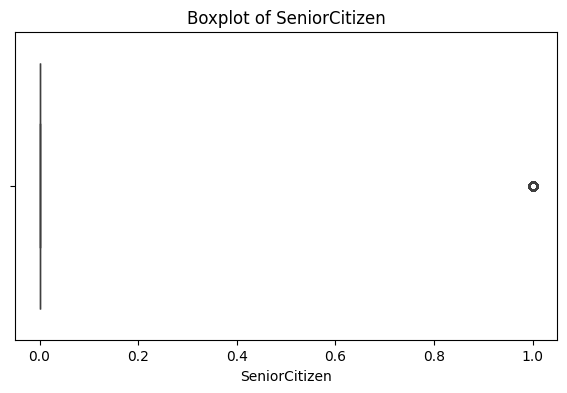

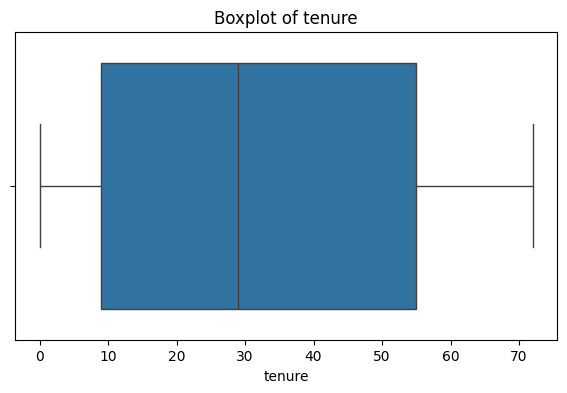

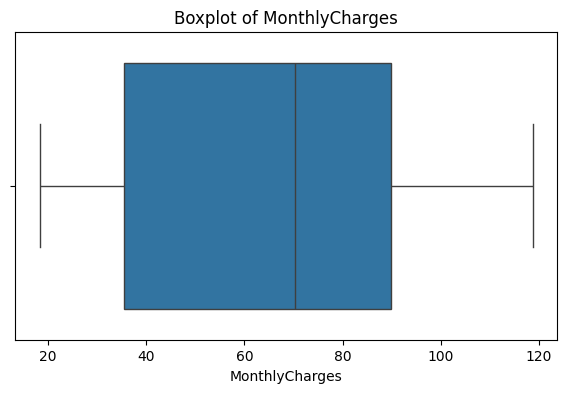

In [6]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[column])

    plt.title("Boxplot of " + column)
    plt.xlabel(column)

    plt.show()

### Boxplot Analysis

Boxplots were created for all numerical attributes to visually inspect their distributions and identify potential outliers.

The box in each plot represents the interquartile range between Q1 and Q3, while the line inside the box represents the median. Values located outside the whiskers may indicate potential outliers.

The boxplots complement the IQR calculations by providing a visual representation of the spread, central tendency, and possible extreme values in the numerical attributes.